In [1]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras import activations
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from numpy import random

**Data Preparation**

In [2]:
N = 28 # number of rows and columns of the input square matrix
C = 10 # number of total classes (e.g. , 10 possible digits )
 # load the data and split it between train and test sets
( x_train , labels_train ) , ( x_test , labels_test ) = keras . datasets . mnist . load_data () # uint8 (0 -255)
print (" Input data type :", x_train . dtype )
print (" Min value :", x_train . min () )
print (" Max value :", x_train . max () )
print (" Shape of the training examples :", x_train . shape )
print (" Shape of the test examples :", x_test . shape )
# scale images to the [0 , 1] range
x_train = x_train / 255
x_test = x_test / 255
print (" Input data type ( after scaling ):", x_train . dtype )
print (" Min value ( after scaling ):", x_train . min () )
print (" Max value ( after scaling ):", x_train . max () )

 # make sure images have shape (28 , 28 , 1)
n_examples_train = x_train . shape [0]
n_examples_test = x_test . shape [0]
x_train = x_train . reshape (( n_examples_train , N , N , 1) )
x_test = x_test . reshape (( n_examples_test , N , N , 1) )

print (" Shape of the training examples ( after reshaping ):", x_train . shape )
print (" Shape of the test examples ( after reshaping ):", x_test . shape )

 # convert labels to one - hot encoded labels using a custom method (to be defined in the exercises 11 and 12)
print (" Shape of the trainin labels :", labels_train . shape )
print (" Shape of the test labels :", labels_test . shape )
y_train =  keras.utils.to_categorical ( labels_train , C )
y_test =  keras.utils.to_categorical ( labels_test , C)
print (" Shape of the trainin labels ( after one - hot encoding ):", y_train . shape )
print (" Shape of the test labels ( after one - hot encoding ):", y_test . shape )


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 Input data type : uint8
 Min value : 0
 Max value : 255
 Shape of the training examples : (60000, 28, 28)
 Shape of the test examples : (10000, 28, 28)
 Input data type ( after scaling ): float64
 Min value ( after scaling ): 0.0
 Max value ( after scaling ): 1.0
 Shape of the training examples ( after reshaping ): (60000, 28, 28, 1)
 Shape of the test examples ( after reshaping ): (10000, 28, 28, 1)
 Shape of the trainin labels : (60000,)
 Shape of the test labels : (10000,)
 Shape of the trainin labels ( after one - hot encoding ): (60000, 10)
 Shape of the test labels ( after one - hot encoding ): (10000, 10)


**Neural Network Design**

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,362 (298.29 KB)

 Trainable params: 76,362 (298.29 KB)

 Non-trainable params: 0 (0.00 B)

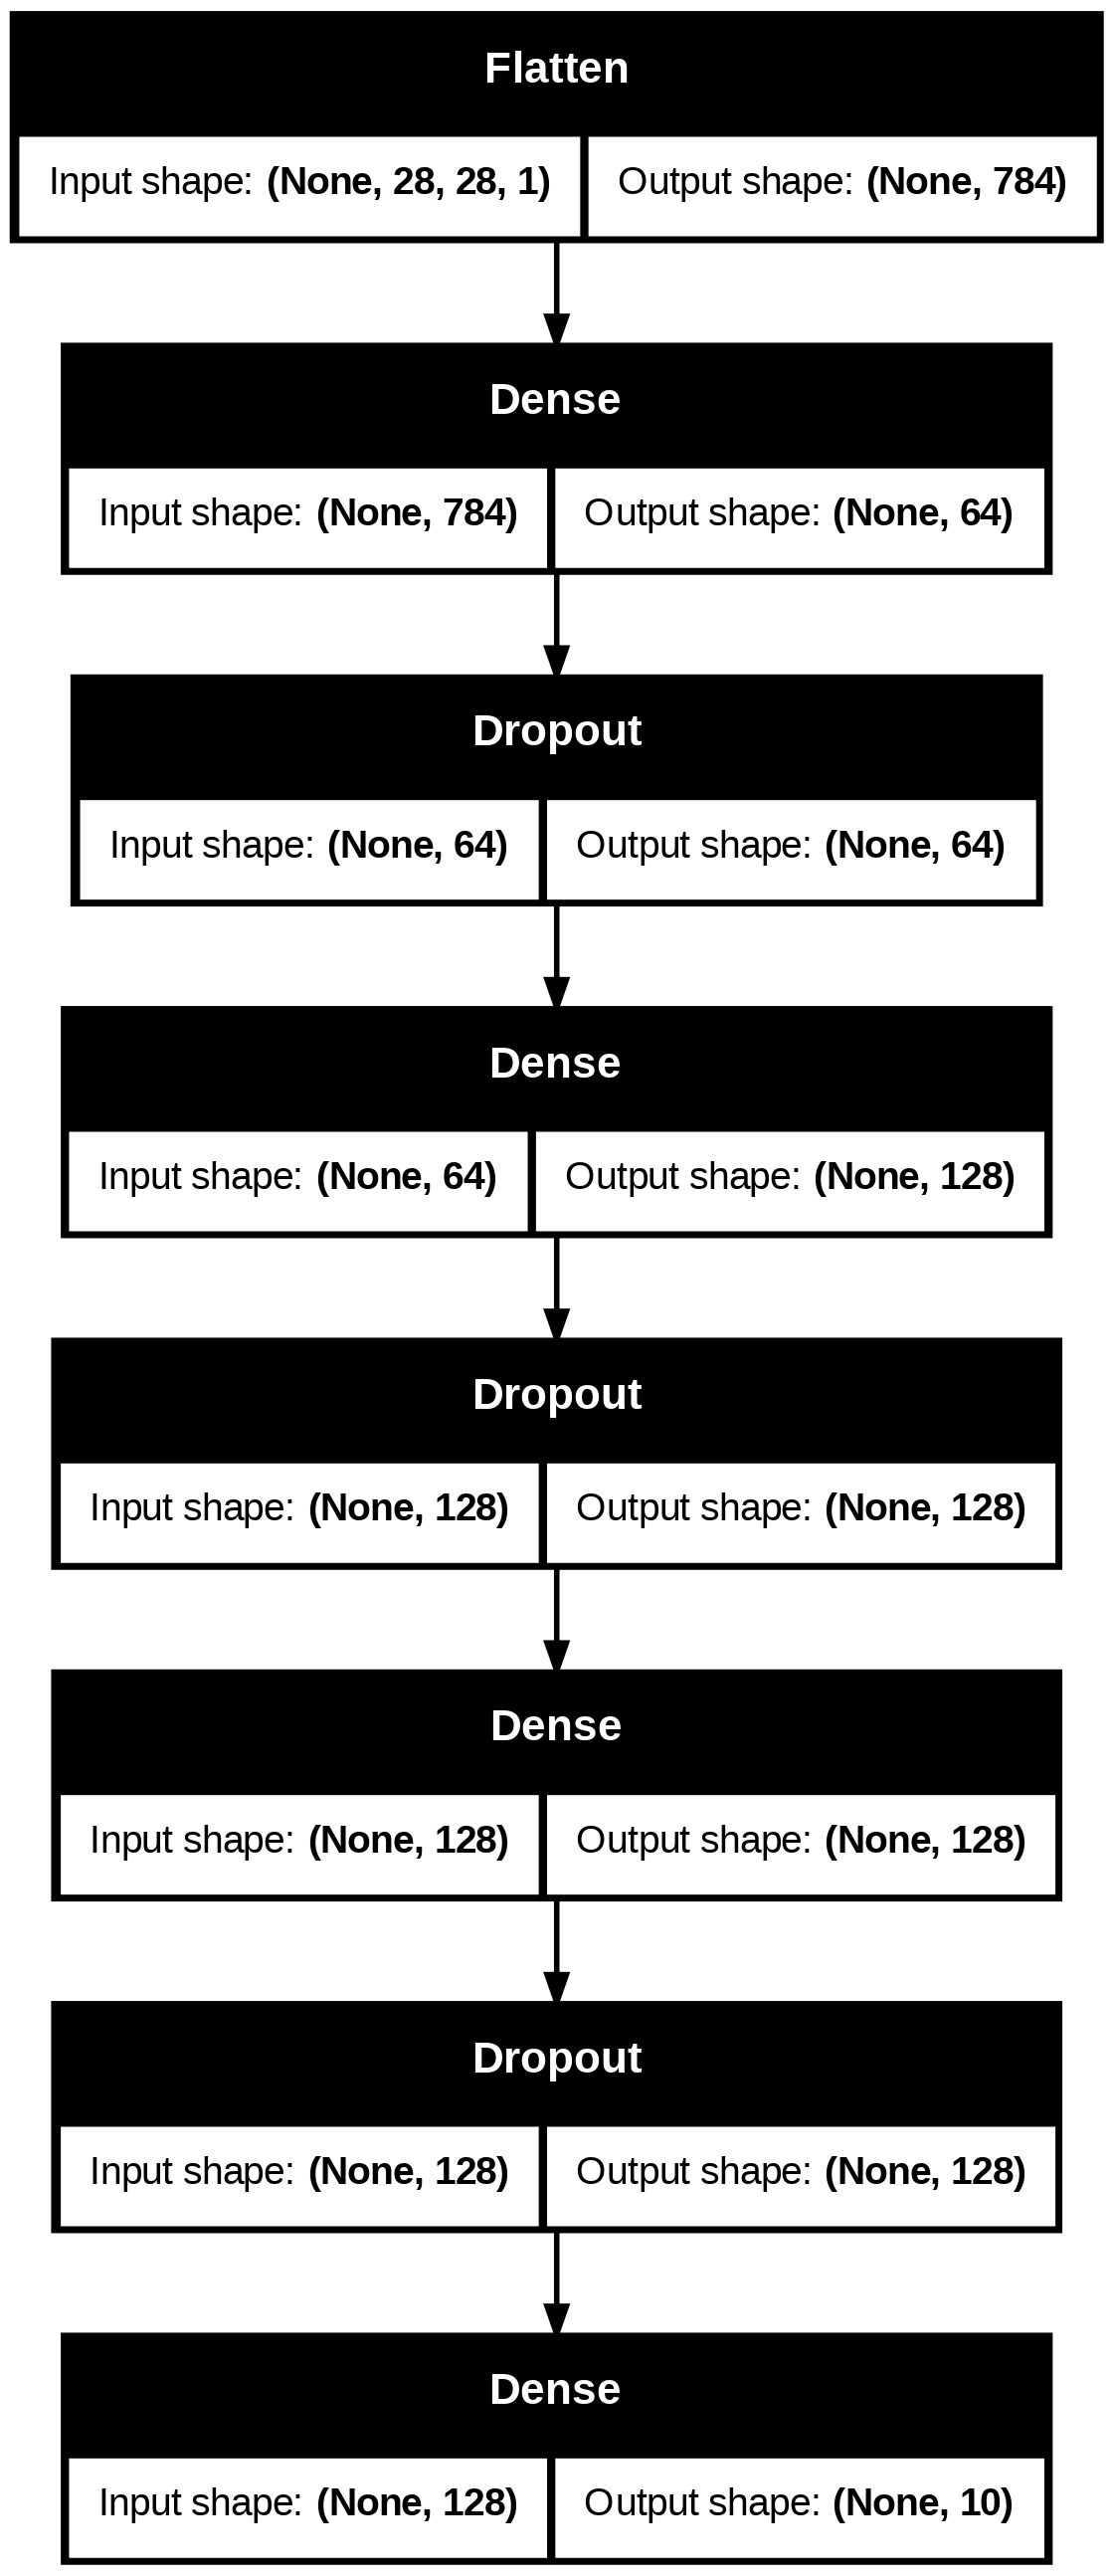

In [24]:
input_shape = (N , N , 1) # input dimension (grey - scale image 28 x 28 , represented as a single input feature map 28 x28x1 )

 # model design
model = keras.Sequential (
[
 keras.Input ( shape = input_shape ) , # input layer
 keras.layers.Flatten () , # flatten layer ( from multiple dimensions to a 1 -D)

 keras.layers.Dense (64 , activation = 'relu') , # 1-D layer of 64 neurons , fully -
#connected with the preceding layer , activated via rectified linear function ( ReLUs )
keras.layers.Dropout (0.25) , # application of dropout to the output of the
#preceding layer with a dropout probability of 0.25 (25% neurons dropped out during
#training )

 keras.layers.Dense (128 , activation ='relu') , # 1 -D layer of 128 neurons , fully -
#connected with the preceding layer , activated via rectified linear function ( ReLUs )
keras.layers.Dropout (0.25) , # application of dropout to the output of the
#preceding layer with a dropout probability of 0.25 (25% neurons dropped out during
#training )

 keras.layers.Dense (128 , activation ='relu') , # 1 -D layer of 128 neurons , fully -
#connected with the preceding layer , activated via rectified linear function ( ReLUs )
 keras.layers.Dropout (0.25) , # application of dropout to the output of the
#preceding layer with a dropout probability of 0.25 (25% neurons dropped out during
#training )

 keras.layers.Dense (C , activation ='softmax') , # output layer with C neurons ,
#fully - connected with the preceding layer , activated via softmax
 ]
 )

 # inspect model
model.summary ()

keras.utils.plot_model(model, show_shapes=True)


**Neural Network Training and plot losses**

Epoch 1/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.1958 - loss: 2.1951 - val_accuracy: 0.7397 - val_loss: 1.2701
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5821 - loss: 1.3051 - val_accuracy: 0.8340 - val_loss: 0.6309
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7143 - loss: 0.8770 - val_accuracy: 0.8710 - val_loss: 0.4736
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7733 - loss: 0.7120 - val_accuracy: 0.8880 - val_loss: 0.4021
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8088 - loss: 0.6060 - val_accuracy: 0.8993 - val_loss: 0.3584
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8303 - loss: 0.5525 - val_accuracy: 0.9085 - val_loss: 0.3264
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8474 - loss: 0.5055 - val_accuracy: 0.9128 - val_loss: 0.3046
Epoch 8/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8562 - loss: 0.4761 - val_accu

/tmp/ipython-input-484688547.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc = 'upper right')


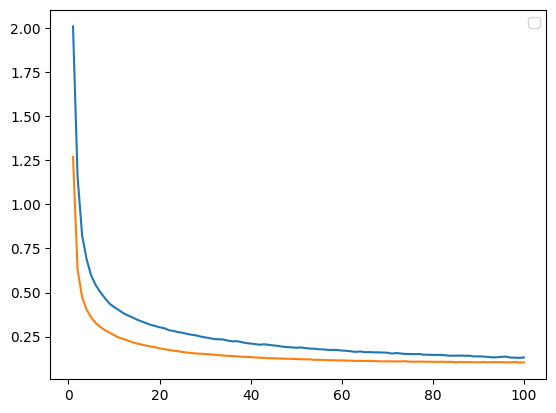

In [4]:
lr = 0.001 # learning rate
momentum = 0.9 # momentum term
# defining the optimizer ( stochastic gradient descent with momentum )
optimizer = keras.optimizers.SGD ( learning_rate = lr , momentum = momentum ) # SGD with
#momentum

# compiling the model = defining the desired loss function to be minimized , the
#algorithm to use for the optimization process, and other metrics to track
model.compile ( loss ='categorical_crossentropy', optimizer = optimizer , metrics =["accuracy"])

valid_ratio = 0.1 # ratio of the overall training set to held back as validation set
 # extracting the validation set as the first 10% of examples
x_valid = x_train [: round ( valid_ratio * n_examples_train ) ,: ,: ,:]
y_valid = y_train [: round ( valid_ratio * n_examples_train ) ,:]
labels_valid = labels_train [: round ( valid_ratio * n_examples_train )]
 # assigning back the training set as the remaining 90% of examples
x_train = x_train [ round ( valid_ratio * n_examples_train ) : ,: ,: ,:]
y_train = y_train [ round ( valid_ratio * n_examples_train ) : ,:]
labels_train = labels_train [ round ( valid_ratio * n_examples_train ) :]


 # defining the ModelCheckpoint callback
model_checkpoint_callback = keras.callbacks.ModelCheckpoint (
filepath ='best_mdl.keras', # set to ’best_mdl . keras ’ if you want only the best
#model , overall or to ’{ epoch :02 d} -{ val_loss :.5 f}. keras ’ if you want to save the
#best model as the training proceed ( best model over time )
monitor ='val_loss', # set to the metric that you want to track for the early
#stopped model ( evaluated offline )
 save_best_only = True )

 # start optimizing the network
batch_size = 128 # mini - batch size
max_epochs = 100 # maximum number of epochs
history = model.fit ( x_train , y_train ,
batch_size = batch_size ,
epochs = max_epochs ,
validation_data =( x_valid , y_valid ) ,
callbacks =[ model_checkpoint_callback ])

 # extracting training and validation losses , training and validation accuracies
train_loss = history.history ['loss']
train_acc = history.history ['accuracy']
valid_loss = history.history ['val_loss']
valid_acc = history.history ['val_accuracy']


xaxis = np.linspace(1,max_epochs,max_epochs)
plt.figure()
plt.plot(xaxis, history.history['loss'], xaxis,history.history['val_loss'])
plt.legend(loc = 'upper right')

In [5]:
xaxis = np.linspace(1,max_epochs,max_epochs)
print(xaxis.shape)
print(xaxis)

(100,)
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100.]


**Trained Network evaluation and accuracy computation**

In [6]:
model = keras.models.load_model ('best_mdl.keras')
proba_test = model.predict ( x_test )
proba_valid = model.predict( x_valid )
proba_train = model.predict( x_train )

print(proba_test)
print(proba_test.shape)
which_number_is_it = np.argmax(proba_test, axis=1)
print(which_number_is_it.shape)
print(which_number_is_it);
print('Length of labels_test:',labels_test.shape)
print(type(labels_test))
print(type(which_number_is_it))
#plt.figure()
#plt.plot(labels_test,which_number_is_it,'p')

y_pred_valid = np.argmax(proba_valid, axis=1)
y_pred_train = np.argmax(proba_train, axis=1)

print(labels_test)
print(type(labels_test))
print((which_number_is_it == labels_test).shape)





accuracy_test = np.sum(which_number_is_it == labels_test)*100/len(labels_test)
accuracy_valid = np.sum(y_pred_valid == labels_valid)*100/len(labels_valid)
accuracy_train = np.sum(y_pred_train == labels_train)*100/len(labels_train)
print('Accuracy on test set: ',accuracy_test)
print('Accuracy on validation set: ',accuracy_valid)
print('Accuracy on train set: ',accuracy_train)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 949us/step
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 929us/step
[[4.4786020e-07 1.6742282e-06 8.0387756e-05 ... 9.9981713e-01
  6.7929541e-08 2.0322263e-05]
 [1.4460464e-06 2.6726782e-05 9.9967188e-01 ... 1.2775550e-06
  4.3736045e-06 8.8713714e-10]
 [5.7046923e-06 9.9899447e-01 2.4348982e-04 ... 3.1413941e-04
  3.1828828e-04 1.0445241e-05]
 ...
 [3.8770210e-08 1.2655748e-07 7.0892486e-07 ... 1.8633604e-05
  1.0549569e-06 2.4078299e-04]
 [2.8450846e-05 7.1619343e-07 5.2349429e-07 ... 3.2497724e-08
  9.8574325e-05 3.0865656e-06]
 [2.7184344e-06 2.0983812e-09 2.3891191e-06 ... 2.5943794e-09
  7.7580616e-08 1.5326324e-11]]
(10000, 10)
(10000,)
[7 2 1 ... 4 5 6]
Length of labels_test: (10000,)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
[7 2 1 ... 4 5 6]
<class 'numpy.ndarray'>
(10000,)
Accuracy on test set:  97.19
Accuracy on validation set:  97.08333333333333
Accuracy on train set:  98.30185185185185


**Confusion matrices plot**

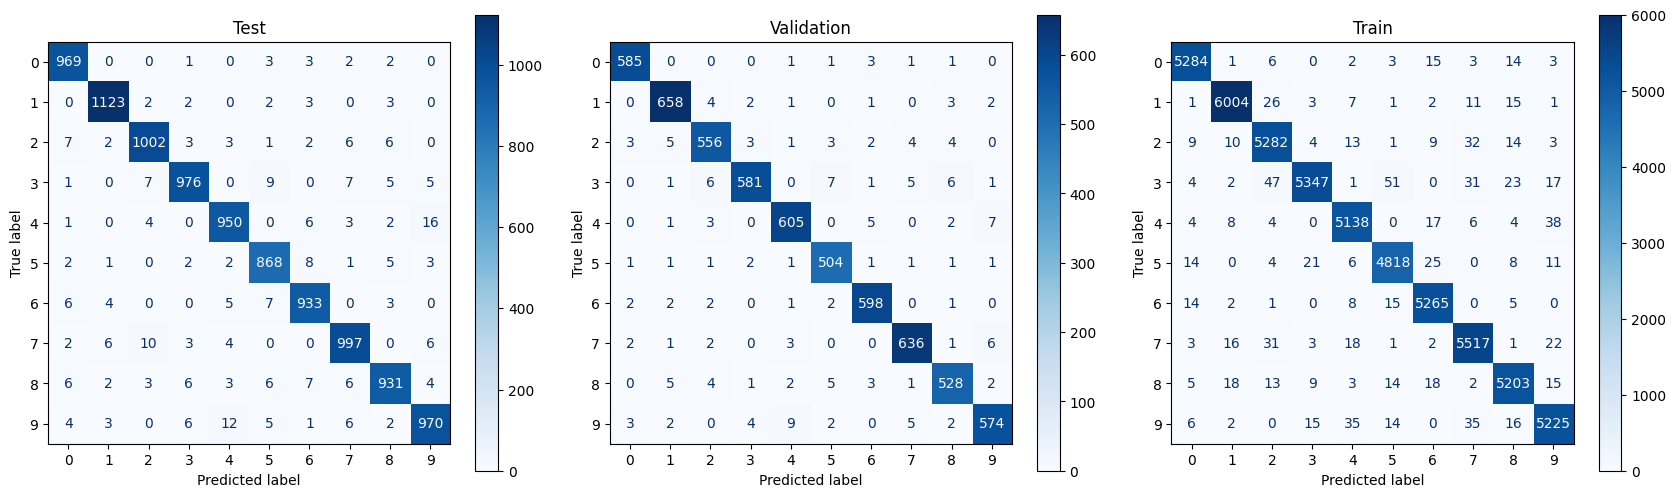

In [7]:
cm_test = confusion_matrix(labels_test, which_number_is_it)
cm_valid = confusion_matrix(labels_valid, y_pred_valid)
cm_train = confusion_matrix(labels_train, y_pred_train)
#print(cm_test)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=np.arange(10))
disp.plot(cmap='Blues', values_format='d',ax = axes[0])  # 'd' = integer counts [web:3][web:7]
axes[0].set_title('Test')


disp = ConfusionMatrixDisplay(confusion_matrix=cm_valid, display_labels=np.arange(10))
disp.plot(cmap='Blues', values_format='d',ax=axes[1])  # 'd' = integer counts [web:3][web:7]
axes[1].set_title('Validation')


disp = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=np.arange(10))
disp.plot(cmap='Blues', values_format='d',ax=axes[2])  # 'd' = integer counts [web:3][web:7]
axes[2].set_title('Train')

plt.tight_layout()
plt.show()



**Layer analysis**

In [8]:
model = keras.models.load_model('best_mdl.keras')
layers = model.layers # list containing all trained layers
layer = layers [1] # first fully - connected layer
weights , biases = layer.get_weights() # accessing weights and biases
print('Weights: ', weights)

Weights:  [[-0.06520335  0.06143186 -0.05930903 ... -0.03423866  0.00568184
  -0.07576574]
 [ 0.04541063 -0.06704301  0.03625166 ... -0.01811199  0.0597307
   0.03138921]
 [ 0.01203166  0.01250961 -0.04370084 ...  0.05019482  0.07986604
  -0.00160057]
 ...
 [ 0.00907637 -0.030768    0.04701602 ...  0.05664565  0.08358277
   0.01731534]
 [ 0.07940146  0.04542791 -0.0779722  ...  0.06701849 -0.05729948
  -0.0795425 ]
 [ 0.0557948  -0.00479045 -0.01848479 ...  0.0766409  -0.04790669
  -0.00512139]]


**Model testing on a random image**

(1, 28, 28)


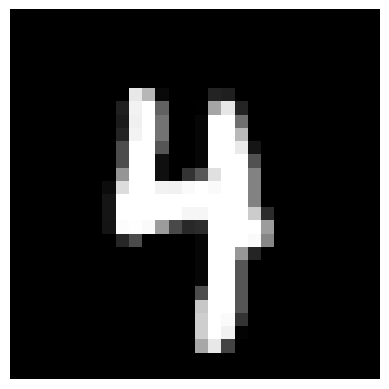

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[[7.5605996e-08 6.2706597e-08 2.5146626e-06 3.7130130e-07 9.9970019e-01
  8.8640554e-06 3.9828760e-06 1.8612142e-05 6.4053205e-07 2.6466753e-04]]
4
Indovinato


In [23]:
idx = random.randint(0, 10000-1)

trial = x_test[idx:idx+1, :, :, :]   # shape (1, 28, 28, 1)

# Option 2: start from (28, 28, 1) and add axis

img = x_test[idx, :, :, 0]      # (28, 28)
trial = np.expand_dims(img, axis=0)  # shape (1, 28, 28, 1)

print(trial.shape)

plt.figure()
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()


y_prob_trial = model.predict(trial);
print(y_prob_trial)
y_pred_trial = np.argmax(y_prob_trial)
print(y_pred_trial)
if y_pred_trial == labels_test[idx]:
  print("Indovinato")
